In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [3]:
project_root = Path.cwd()

if project_root.name == "notebooks":
    project_root = project_root.parent

data_directory = project_root / "data"
data_directory.mkdir(exist_ok=True)

In [4]:
stock_data = {
    "date": [
        "2026-01-02", "2026-01-02", "2026-01-02",
        "2026-01-05", "2026-01-05", "2026-01-05",
        "2026-01-06", "2026-01-06", "2026-01-06",
        "2026-01-07", "2026-01-07", "2026-01-07",
    ],
    "ticker": [
        "AAPL", "MSFT", "GOOG",
        "AAPL", "MSFT", "GOOG",
        "AAPL", "MSFT", "GOOG",
        "AAPL", "MSFT", "GOOG",
    ],
    "open": [
        195.0, 420.0, 175.0,
        196.5, 422.0, 176.0,
        194.0, 425.0, 177.5,
        198.0, 424.0, 179.0,
    ],
    "high": [
        197.0, 424.0, 177.0,
        198.0, 426.0, 178.5,
        196.0, 428.0, 180.0,
        201.0, 427.0, 181.0,
    ],
    "low": [
        193.5, 418.0, 173.5,
        194.5, 420.0, 174.5,
        192.5, 422.0, 176.0,
        196.0, 421.0, 177.5,
    ],
    "close": [
        196.0, 423.0, 176.0,
        np.nan, 425.0, 177.5,
        195.5, 424.0, 179.0,
        200.0, 426.0, 180.5,
    ],
    "volume": [
        1_200_000, 900_000, 750_000,
        1_350_000, 980_000, 800_000,
        1_100_000, np.nan, 820_000,
        1_500_000, 1_050_000, 870_000,
    ],
}

raw_df = pd.DataFrame(stock_data)

raw_df

,date,ticker,open,high,low,close,volume
0,2026-01-02,AAPL,195.0,197.0,193.5,196.0,1200000.0
1,2026-01-02,MSFT,420.0,424.0,418.0,423.0,900000.0
2,2026-01-02,GOOG,175.0,177.0,173.5,176.0,750000.0
3,2026-01-05,AAPL,196.5,198.0,194.5,NaN,1350000.0
4,2026-01-05,MSFT,422.0,426.0,420.0,425.0,980000.0
5,2026-01-05,GOOG,176.0,178.5,174.5,177.5,800000.0
6,2026-01-06,AAPL,194.0,196.0,192.5,195.5,1100000.0
7,2026-01-06,MSFT,425.0,428.0,422.0,424.0,NaN
8,2026-01-06,GOOG,177.5,180.0,176.0,179.0,820000.0
9,2026-01-07,AAPL,198.0,201.0,196.0,200.0,1500000.0


In [6]:
raw_df = pd.concat(
    [raw_df, raw_df.iloc[[0]]],
     ignore_index = True
    )

csv_path = data_directory / "pandas_practice.csv"
raw_df.to_csv(csv_path, index = False)

print(csv_path)

/Users/omurravli/Desktop/pythorch_stock_predict/data/pandas_practice.csv


In [7]:
df = pd.read_csv(csv_path)

print(df)

          date ticker   open   high    low  close     volume
0   2026-01-02   AAPL  195.0  197.0  193.5  196.0  1200000.0
1   2026-01-02   MSFT  420.0  424.0  418.0  423.0   900000.0
2   2026-01-02   GOOG  175.0  177.0  173.5  176.0   750000.0
3   2026-01-05   AAPL  196.5  198.0  194.5    NaN  1350000.0
4   2026-01-05   MSFT  422.0  426.0  420.0  425.0   980000.0
5   2026-01-05   GOOG  176.0  178.5  174.5  177.5   800000.0
6   2026-01-06   AAPL  194.0  196.0  192.5  195.5  1100000.0
7   2026-01-06   MSFT  425.0  428.0  422.0  424.0        NaN
8   2026-01-06   GOOG  177.5  180.0  176.0  179.0   820000.0
9   2026-01-07   AAPL  198.0  201.0  196.0  200.0  1500000.0
10  2026-01-07   MSFT  424.0  427.0  421.0  426.0  1050000.0
11  2026-01-07   GOOG  179.0  181.0  177.5  180.5   870000.0
12  2026-01-02   AAPL  195.0  197.0  193.5  196.0  1200000.0


In [15]:
print("Shape: ", df.shape)
print("Columns: ", df.columns.to_list())

df.head()

df.info()
df.describe()

Shape:  (13, 7)
Columns:  ['date', 'ticker', 'open', 'high', 'low', 'close', 'volume']
<class 'pandas.DataFrame'>
RangeIndex: 13 entries, 0 to 12
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    13 non-null     str    
 1   ticker  13 non-null     str    
 2   open    13 non-null     float64
 3   high    13 non-null     float64
 4   low     13 non-null     float64
 5   close   12 non-null     float64
 6   volume  12 non-null     float64
dtypes: float64(5), str(2)
memory usage: 860.0 bytes


,open,high,low,close,volume
count,13.000000,13.000000,13.000000,12.000000,1.200000e+01
mean,259.769231,262.346154,257.884615,266.541667,1.043333e+06
std,113.392683,114.026566,112.957432,116.941411,2.344562e+05
min,175.000000,177.000000,173.500000,176.000000,7.500000e+05
25%,179.000000,181.000000,177.500000,180.125000,8.575000e+05
50%,195.000000,197.000000,193.500000,196.000000,1.015000e+06
75%,420.000000,424.000000,418.000000,423.250000,1.200000e+06
max,425.000000,428.000000,422.000000,426.000000,1.500000e+06


In [16]:
df["date"] = pd.to_datetime(df["date"])

In [17]:
print("Missing Values: ")
print(df.isna().sum())

Missing Values: 
date      0
ticker    0
open      0
high      0
low       0
close     1
volume    1
dtype: int64


In [19]:
print("Duplicate Rows: ")
print(df.duplicated().sum())

Duplicate Rows: 
1


In [20]:
df = df.drop_duplicates().copy()

print("New Shape: ", df.shape)

New Shape:  (12, 7)


In [21]:
df = df.sort_values(by=["ticker", "date"]).reset_index(drop=True)

In [22]:
df

,date,ticker,open,high,low,close,volume
0,2026-01-02,AAPL,195.0,197.0,193.5,196.0,1200000.0
1,2026-01-05,AAPL,196.5,198.0,194.5,NaN,1350000.0
2,2026-01-06,AAPL,194.0,196.0,192.5,195.5,1100000.0
3,2026-01-07,AAPL,198.0,201.0,196.0,200.0,1500000.0
4,2026-01-02,GOOG,175.0,177.0,173.5,176.0,750000.0
5,2026-01-05,GOOG,176.0,178.5,174.5,177.5,800000.0
6,2026-01-06,GOOG,177.5,180.0,176.0,179.0,820000.0
7,2026-01-07,GOOG,179.0,181.0,177.5,180.5,870000.0
8,2026-01-02,MSFT,420.0,424.0,418.0,423.0,900000.0
9,2026-01-05,MSFT,422.0,426.0,420.0,425.0,980000.0


In [25]:
df["close"] = (df.groupby("ticker")["close"].transform(lambda values: values.interpolate()))

In [26]:
df["volume"] = (
    df.groupby("ticker")["volume"].transform(
        lambda values: values.fillna(values.median())))

In [27]:
print(df.isna().sum())

date      0
ticker    0
open      0
high      0
low       0
close     0
volume    0
dtype: int64


In [28]:
close_series = df["close"]

print(type(close_series))
close_series.head()

<class 'pandas.Series'>


0    196.00
1    195.75
2    195.50
3    200.00
4    176.00
Name: close, dtype: float64

In [29]:
df

,date,ticker,open,high,low,close,volume
0,2026-01-02,AAPL,195.0,197.0,193.5,196.00,1200000.0
1,2026-01-05,AAPL,196.5,198.0,194.5,195.75,1350000.0
2,2026-01-06,AAPL,194.0,196.0,192.5,195.50,1100000.0
3,2026-01-07,AAPL,198.0,201.0,196.0,200.00,1500000.0
4,2026-01-02,GOOG,175.0,177.0,173.5,176.00,750000.0
5,2026-01-05,GOOG,176.0,178.5,174.5,177.50,800000.0
6,2026-01-06,GOOG,177.5,180.0,176.0,179.00,820000.0
7,2026-01-07,GOOG,179.0,181.0,177.5,180.50,870000.0
8,2026-01-02,MSFT,420.0,424.0,418.0,423.00,900000.0
9,2026-01-05,MSFT,422.0,426.0,420.0,425.00,980000.0


In [30]:
price_dataframe = df[
    ["date", "ticker", "open", "close"]]

print(type(price_dataframe))
price_dataframe.head()

<class 'pandas.DataFrame'>


,date,ticker,open,close
0,2026-01-02,AAPL,195.0,196.00
1,2026-01-05,AAPL,196.5,195.75
2,2026-01-06,AAPL,194.0,195.50
3,2026-01-07,AAPL,198.0,200.00
4,2026-01-02,GOOG,175.0,176.00


In [33]:
filtered_df = df.loc[
    (df["close"] > 180) & (df["volume"] > 1_000_000),
    ["date", "ticker", "close", "volume"]]

filtered_df

,date,ticker,close,volume
0,2026-01-02,AAPL,196.00,1200000.0
1,2026-01-05,AAPL,195.75,1350000.0
2,2026-01-06,AAPL,195.50,1100000.0
3,2026-01-07,AAPL,200.00,1500000.0
11,2026-01-07,MSFT,426.00,1050000.0


In [34]:
df["daily_range"] = df["high"] - df ["low"]

df[["date", "ticker", "high", "low", "daily_range"]].head()

,date,ticker,high,low,daily_range
0,2026-01-02,AAPL,197.0,193.5,3.5
1,2026-01-05,AAPL,198.0,194.5,3.5
2,2026-01-06,AAPL,196.0,192.5,3.5
3,2026-01-07,AAPL,201.0,196.0,5.0
4,2026-01-02,GOOG,177.0,173.5,3.5


In [35]:
df["daily_return_pct"] = (
    df.groupby("ticker")["close"].pct_change() * 100 )

df[["date", "ticker", "close", "daily_return_pct"]]

,date,ticker,close,daily_return_pct
0,2026-01-02,AAPL,196.00,NaN
1,2026-01-05,AAPL,195.75,-0.127551
2,2026-01-06,AAPL,195.50,-0.127714
3,2026-01-07,AAPL,200.00,2.301790
4,2026-01-02,GOOG,176.00,NaN
5,2026-01-05,GOOG,177.50,0.852273
6,2026-01-06,GOOG,179.00,0.845070
7,2026-01-07,GOOG,180.50,0.837989
8,2026-01-02,MSFT,423.00,NaN
9,2026-01-05,MSFT,425.00,0.472813


In [36]:
summary = (
    df.groupby("ticker").agg(
        average_close = ("close", "mean"),
        highest_close = ("close", "max"),
        lowest_close = ("close", "min"),
        total_volume = ("volume", "sum"),
        average_return_pct = ("daily_return_pct", "mean"),)
    .round(2)
    )
summary

,average_close,highest_close,lowest_close,total_volume,average_return_pct
ticker,,,,,
AAPL,196.81,200.0,195.5,5150000.0,0.68
GOOG,178.25,180.5,176.0,3240000.0,0.85
MSFT,424.50,426.0,423.0,3910000.0,0.24


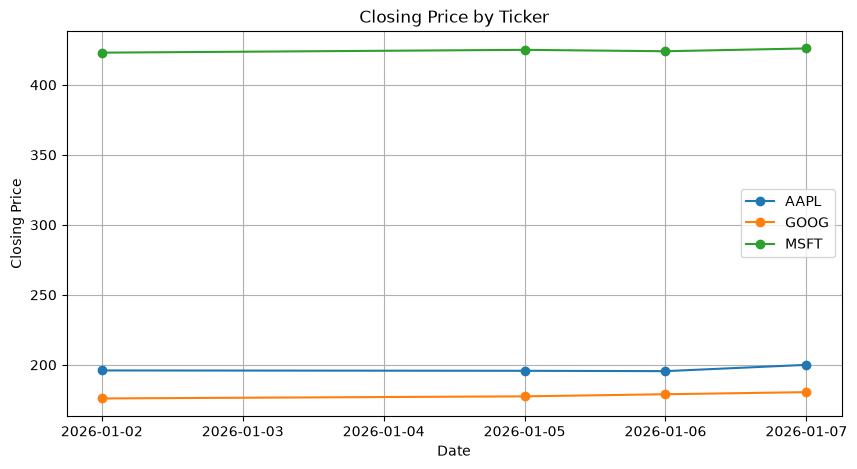

In [37]:
plt.figure(figsize=(10,5))

for ticker, ticker_df in df.groupby("ticker"):
    plt.plot(
        ticker_df["date"],
        ticker_df["close"],
        marker="o",
        label=ticker
    )

plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.title("Closing Price by Ticker")
plt.legend()
plt.grid(True)
plt.show()

In [38]:
cleaned_csv_path = (
    data_directory / "pandas_practice_cleaned.csv")

df.to_csv(cleaned_csv_path, index = False)

print("Saved to: ", cleaned_csv_path)

Saved to:  /Users/omurravli/Desktop/pythorch_stock_predict/data/pandas_practice_cleaned.csv


In [40]:
df["volume"].idxmax()

3

In [41]:
print(df["volume"].idxmax())

3


In [42]:
df.loc[[df["volume"].idxmax()]]

,date,ticker,open,high,low,close,volume,daily_range,daily_return_pct
3,2026-01-07,AAPL,198.0,201.0,196.0,200.0,1500000.0,5.0,2.30179


In [43]:
df["ticker"] == "MSFT"

0     False
1     False
2     False
3     False
4     False
5     False
6     False
7     False
8      True
9      True
10     True
11     True
Name: ticker, dtype: bool

In [44]:
df[df["ticker"] == "MSFT"]

,date,ticker,open,high,low,close,volume,daily_range,daily_return_pct
8,2026-01-02,MSFT,420.0,424.0,418.0,423.0,900000.0,6.0,NaN
9,2026-01-05,MSFT,422.0,426.0,420.0,425.0,980000.0,6.0,0.472813
10,2026-01-06,MSFT,425.0,428.0,422.0,424.0,980000.0,6.0,-0.235294
11,2026-01-07,MSFT,424.0,427.0,421.0,426.0,1050000.0,6.0,0.471698


In [45]:
df["daily_return_pct"] > 0

0     False
1     False
2     False
3      True
4     False
5      True
6      True
7      True
8     False
9      True
10    False
11     True
Name: daily_return_pct, dtype: bool

In [46]:
df[df["daily_return_pct"] > 0]

,date,ticker,open,high,low,close,volume,daily_range,daily_return_pct
3,2026-01-07,AAPL,198.0,201.0,196.0,200.0,1500000.0,5.0,2.301790
5,2026-01-05,GOOG,176.0,178.5,174.5,177.5,800000.0,4.0,0.852273
6,2026-01-06,GOOG,177.5,180.0,176.0,179.0,820000.0,4.0,0.845070
7,2026-01-07,GOOG,179.0,181.0,177.5,180.5,870000.0,3.5,0.837989
9,2026-01-05,MSFT,422.0,426.0,420.0,425.0,980000.0,6.0,0.472813
11,2026-01-07,MSFT,424.0,427.0,421.0,426.0,1050000.0,6.0,0.471698


In [49]:
df.sort_values(by="daily_return_pct", ascending=False)

,date,ticker,open,high,low,close,volume,daily_range,daily_return_pct
3,2026-01-07,AAPL,198.0,201.0,196.0,200.00,1500000.0,5.0,2.301790
5,2026-01-05,GOOG,176.0,178.5,174.5,177.50,800000.0,4.0,0.852273
6,2026-01-06,GOOG,177.5,180.0,176.0,179.00,820000.0,4.0,0.845070
7,2026-01-07,GOOG,179.0,181.0,177.5,180.50,870000.0,3.5,0.837989
9,2026-01-05,MSFT,422.0,426.0,420.0,425.00,980000.0,6.0,0.472813
11,2026-01-07,MSFT,424.0,427.0,421.0,426.00,1050000.0,6.0,0.471698
1,2026-01-05,AAPL,196.5,198.0,194.5,195.75,1350000.0,3.5,-0.127551
2,2026-01-06,AAPL,194.0,196.0,192.5,195.50,1100000.0,3.5,-0.127714
10,2026-01-06,MSFT,425.0,428.0,422.0,424.00,980000.0,6.0,-0.235294
0,2026-01-02,AAPL,195.0,197.0,193.5,196.00,1200000.0,3.5,NaN
